<a href="https://colab.research.google.com/github/letter-b/lab-web-scraping/blob/main/LAB_web_scraping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab | Web Scraping

Welcome to the "Books to Scrape" Web Scraping Adventure Lab!

**Objective**

In this lab, we will embark on a mission to unearth valuable insights from the data available on Books to Scrape, an online platform showcasing a wide variety of books. As data analyst, you have been tasked with scraping a specific subset of book data from Books to Scrape to assist publishing companies in understanding the landscape of highly-rated books across different genres. Your insights will help shape future book marketing strategies and publishing decisions.

**Background**

In a world where data has become the new currency, businesses are leveraging big data to make informed decisions that drive success and profitability. The publishing industry, much like others, utilizes data analytics to understand market trends, reader preferences, and the performance of books based on factors such as genre, author, and ratings. Books to Scrape serves as a rich source of such data, offering detailed information about a diverse range of books, making it an ideal platform for extracting insights to aid in informed decision-making within the literary world.

**Task**

Your task is to create a Python script using BeautifulSoup and pandas to scrape Books to Scrape book data, focusing on book ratings and genres. The script should be able to filter books with ratings above a certain threshold and in specific genres. Additionally, the script should structure the scraped data in a tabular format using pandas for further analysis.

**Expected Outcome**

A function named `scrape_books` that takes two parameters: `min_rating` and `max_price`. The function should scrape book data from the "Books to Scrape" website and return a `pandas` DataFrame with the following columns:

**Expected Outcome**

- A function named `scrape_books` that takes two parameters: `min_rating` and `max_price`.
- The function should return a DataFrame with the following columns:
  - **UPC**: The Universal Product Code (UPC) of the book.
  - **Title**: The title of the book.
  - **Price (£)**: The price of the book in pounds.
  - **Rating**: The rating of the book (1-5 stars).
  - **Genre**: The genre of the book.
  - **Availability**: Whether the book is in stock or not.
  - **Description**: A brief description or product description of the book (if available).
  
You will execute this script to scrape data for books with a minimum rating of `4.0 and above` and a maximum price of `£20`.

Remember to experiment with different ratings and prices to ensure your code is versatile and can handle various searches effectively!

**Resources**

- [Beautiful Soup Documentation](https://www.crummy.com/software/BeautifulSoup/bs4/doc/)
- [Pandas Documentation](https://pandas.pydata.org/pandas-docs/stable/index.html)
- [Books to Scrape](https://books.toscrape.com/)


**Hint**

Your first mission is to familiarize yourself with the **Books to Scrape** website. Navigate to [Books to Scrape](http://books.toscrape.com/) and explore the available books to understand their layout and structure.

Next, think about how you can set parameters for your data extraction:

- **Minimum Rating**: Focus on books with a rating of 4.0 and above.
- **Maximum Price**: Filter for books priced up to £20.

After reviewing the site, you can construct a plan for scraping relevant data. Pay attention to the details displayed for each book, including the title, price, rating, and availability. This will help you identify the correct HTML elements to target with your scraping script.

Make sure to build your scraping URL and logic based on the patterns you observe in the HTML structure of the book listings!


---

**Best of luck! Immerse yourself in the world of books, and may the data be with you!**

**Important Note**:

In the fast-changing online world, websites often update and change their structures. When you try this lab, the **Books to Scrape** website might differ from what you expect.

If you encounter issues due to these changes, like new rules or obstacles preventing data extraction, don’t worry! Get creative.

You can choose another website that interests you and is suitable for scraping data. Options like Wikipedia, The New York Times, or even library databases are great alternatives. The main goal remains the same: extract useful data and enhance your web scraping skills while exploring a source of information you enjoy. This is your opportunity to practice and adapt to different web environments!

In [8]:
!pip install bs4 requests pandas
import requests
from bs4 import BeautifulSoup
import pandas as pd

In [9]:
BASE_URL = "http://books.toscrape.com/catalogue/"

In [10]:
def get_soup(url):
    response = requests.get(url)
    return BeautifulSoup(response.content, 'html.parser')

def clean_price(price_str):
    return float(price_str[2:])  # Remove '£' and convert to float

def convert_rating(word_rating):
    rating_dict = {'One': 1, 'Two': 2, 'Three': 3, 'Four': 4, 'Five': 5}
    return rating_dict.get(word_rating, 0)

In [11]:
def scrape_books(min_rating=4, max_price=20):
    book_data = []

    for page_number in range(1, 51):  # Assume 50 pages total
        url = f"http://books.toscrape.com/catalogue/page-{page_number}.html"
        soup = get_soup(url)

        books = soup.select('article.product_pod')

        for book in books:
            # Extract book details
            title = book.h3.a['title']
            price = clean_price(book.select_one('.price_color').text)
            availability = 'In stock' if 'In stock' in book.select_one('.availability').text else 'Out of stock'
            rating = convert_rating(book.p['class'][1])

            # Scrape book details from the book's page
            book_url = BASE_URL + book.h3.a['href']
            book_soup = get_soup(book_url)
            genre = book_soup.find('ul', class_='breadcrumb').find_all('a')[-1].text.strip()
            description_tag = book_soup.find('meta', {'name': 'description'})
            description = description_tag.get("content").strip() if description_tag else ''

            # Gather and filter data
            if rating >= min_rating and price <= max_price:
                book_data.append({
                    'Title': title,
                    'Price (£)': price,
                    'Rating': rating,
                    'Genre': genre,
                    'Availability': availability,
                    'Description': description,
                })

    return pd.DataFrame(book_data)

# Call the function with minimum rating 4 and maximum price £20
books_df = scrape_books(min_rating=4, max_price=20)

In [12]:
books_df.head()

,Title,Price (£),Rating,Genre,Availability,Description
0,Sharp Objects,7.82,4,Mystery,In stock,"WICKED above her hipbone, GIRL across her hear..."
1,Sapiens: A Brief History of Humankind,4.23,5,History,In stock,From a renowned historian comes a groundbreaki...
2,The Dirty Little Secrets of Getting Your Dream...,3.34,4,Business,In stock,Drawing on his extensive experience evaluating...
3,The Boys in the Boat: Nine Americans and Their...,2.60,4,Default,In stock,For readers of Laura Hillenbrand's Seabiscuit ...
4,Shakespeare's Sonnets,0.66,4,Poetry,In stock,This book is an important and complete collect...


In [13]:
pd.set_option('display.max_rows', None)  # To show all the rows
pd.set_option('display.max_columns', None)  # To show all the columns

# Now display the entire DataFrame
display(books_df)

,Title,Price (£),Rating,Genre,Availability,Description
0,Sharp Objects,7.82,4,Mystery,In stock,"WICKED above her hipbone, GIRL across her hear..."
1,Sapiens: A Brief History of Humankind,4.23,5,History,In stock,From a renowned historian comes a groundbreaki...
2,The Dirty Little Secrets of Getting Your Dream...,3.34,4,Business,In stock,Drawing on his extensive experience evaluating...
3,The Boys in the Boat: Nine Americans and Their...,2.60,4,Default,In stock,For readers of Laura Hillenbrand's Seabiscuit ...
4,Shakespeare's Sonnets,0.66,4,Poetry,In stock,This book is an important and complete collect...
5,Set Me Free,7.46,5,Young Adult,In stock,Aaron Ledbetter’s future had been planned out ...
6,Scott Pilgrim's Precious Little Life (Scott Pi...,2.29,5,Sequential Art,In stock,Scott Pilgrim's life is totally sweet. He's 23...
7,Rip it Up and Start Again,5.02,5,Music,In stock,"Punk's raw power rejuvenated rock, but by the ..."
8,Chase Me (Paris Nights #2),5.27,5,Romance,In stock,"A Michelin two-star chef at twenty-eight, Viol..."
9,Black Dust,4.53,5,Romance,In stock,"No matter how busy he keeps himself, successfu..."


In [15]:
display((books_df.describe()).round(2))

,Price (£),Rating
count,375.00,375.00
mean,5.00,4.52
std,2.93,0.50
min,0.00,4.00
25%,2.30,4.00
50%,5.06,5.00
75%,7.51,5.00
max,9.99,5.00


In [17]:
#FOR FUN, trying to understand price/rating per genre
genre_stats = books_df.groupby('Genre')[['Price (£)', 'Rating']].mean()
display((genre_stats.head()).round(2))

#Group the books_df DataFrame by 'Genre' and calculate the mean of 'Price (£)' and 'Rating' for each genre. This will give us the average price and rating for books in each category.

,Price (£),Rating
Genre,,
Add a comment,5.19,4.38
Adult Fiction,5.36,5.00
Art,4.75,4.20
Autobiography,6.26,4.75
Business,4.10,4.75


**Reasoning**:
To calculate the average price and rating for each genre, I will group the `books_df` DataFrame by the 'Genre' column and then compute the mean of 'Price (£)' and 'Rating' for each group, storing the result in a new DataFrame named `genre_stats`.



**Reasoning**:
To visualize the average price by genre, I need to import the necessary plotting libraries, `matplotlib.pyplot` and `seaborn`. I will create a bar plot using the genre_stats DataFrame, setting 'Genre' on the x-axis and 'Price (£)' on the y-axis, and then customize the plot for readability.



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
correlation_genre_pr = genre_stats['Price (£)'].corr(genre_stats['Rating'])
print(f"Correlation between Price and Rating: {correlation_genre_pr:.2f}")

#Low positive correlation. This means ratings are not necessarily related to the price of the book.

Correlation between Price and Rating: 0.25


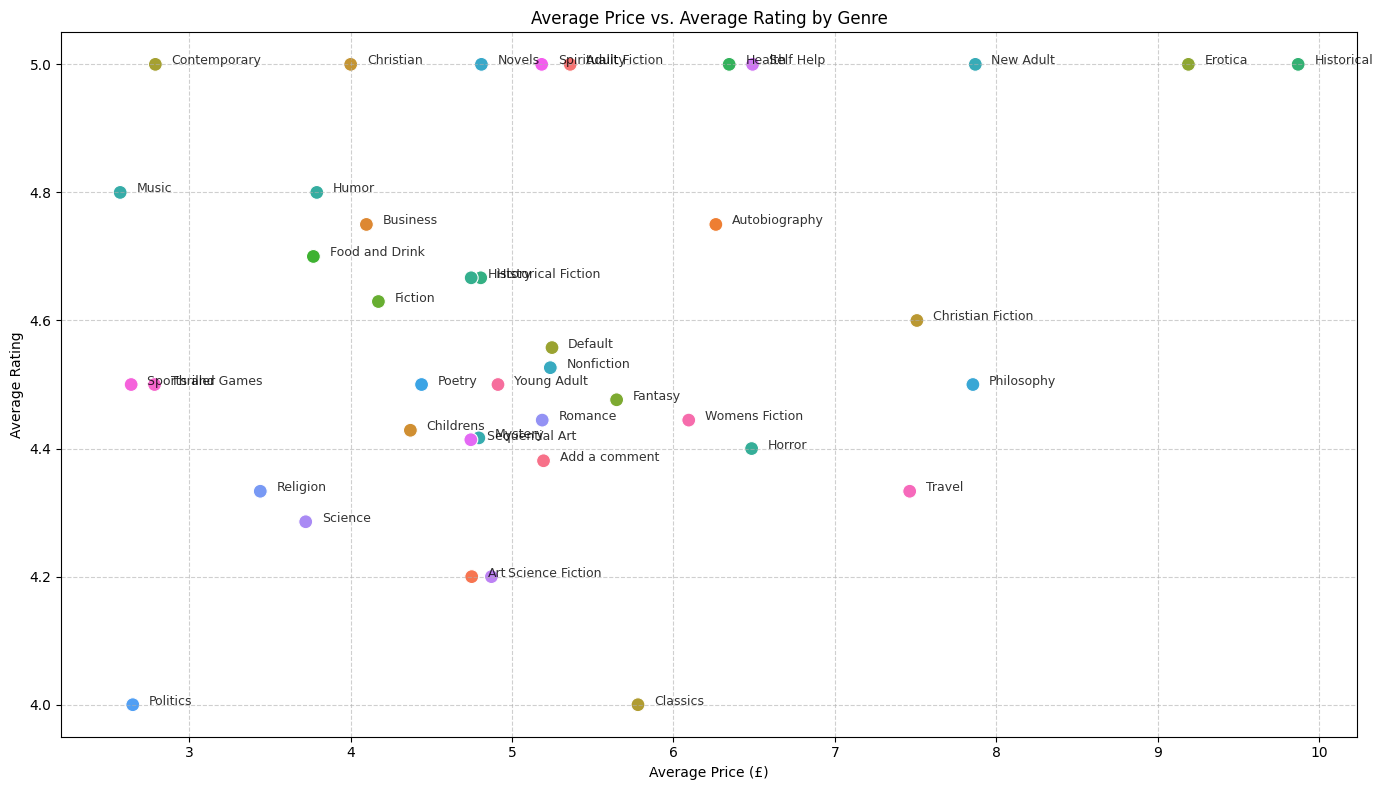

In [20]:
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Price (£)', y='Rating', data=genre_stats, s=100, hue=genre_stats.index, legend=False)

# Annotate points with genre names
for i, (genre, row) in enumerate(genre_stats.iterrows()):
    plt.annotate(genre, (row['Price (£)'] + 0.1, row['Rating']), fontsize=9, alpha=0.8)

plt.title('Average Price vs. Average Rating by Genre')
plt.xlabel('Average Price (£)')
plt.ylabel('Average Rating')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()